In [1]:
quiet_library <- function(...) { suppressPackageStartupMessages(library(...)) }
quiet_library(flowCore)
quiet_library(hise)
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(tidyr)
quiet_library(ggplot2)

Warning message:
“package ‘flowCore’ was built under R version 4.4.2”


In [2]:
if(!dir.exists("output")) {
    dir.create("output")
}

### Retrieve sample information

In [3]:
sample_meta_file_uuid = '2da66a1a-17cc-498b-9129-6858cf639caf'

In [4]:
sample_meta_file <- cacheFiles(list(sample_meta_file_uuid))

[1] "downloading fileID 2da66a1a-17cc-498b-9129-6858cf639caf"


In [5]:
sample_meta <- read.csv(sample_meta_file)

In [6]:
nrow(sample_meta)

[1] 108

### Retrieve panel information

These files list of targets, conjugates, and clones for each feature in the flow cytometry data. These are derived from the tables in Heubeck, et al. (2021).

In [7]:
panel_uuids <- list(
    "PB1" = list("28d563bf-4b35-405d-9136-56b9f1d77f24"),
    "PM1" = list("e4658085-e1a2-40f5-9e89-a3083b1758a6"),
    "PS1" = list("d4349731-4eae-4381-8519-72816b0cb9e7"),
    "PT1" = list("a1c0beeb-b951-4628-956a-2680c0d7230d")
)

In [8]:
panel_files <- map(
    panel_uuids,
    cacheFiles
)

[1] "downloading fileID 28d563bf-4b35-405d-9136-56b9f1d77f24"
[1] "downloading fileID e4658085-e1a2-40f5-9e89-a3083b1758a6"
[1] "downloading fileID d4349731-4eae-4381-8519-72816b0cb9e7"
[1] "downloading fileID a1c0beeb-b951-4628-956a-2680c0d7230d"


In [9]:
panel_files <- map(
    panel_files,
    function(f) {
        paste0("/home/workspace/", f)
    }
)

## Find flow cytometry data

### Labeled, logicle-transformed event data
fileType = FlowCytometry-decoration-report-csv

There should be 4 files for each sample, one per Flow Cytometry panel; 432 in total.

In [10]:
event_desc <- getFileDescriptors(
    fileType = "FlowCytometry-labeled-expr-csv",
    filter = list(
        sample.sampleKitGuid = as.list(sample_meta[["sample.sampleKitGuid"]])
    )
)

In [11]:
event_desc <- fileDescToDataframe(event_desc)
nrow(event_desc)

[1] 517

Some events will be from exactly the same aliquots as the scRNA-seq data.

We can match these based on specimen IDs:

In [12]:
event_desc <- event_desc %>%
  mutate(pbmc_sample_id = sub(".+(PB[0-9]+-[0-9]+).+", "\\1", file.name)) %>%
  mutate(file_date = sub(".+(20[0-9]{2}-[0-9]{2}-[0-9]{2}).+", "\\1", file.name))

In [13]:
matched_event_desc <- event_desc %>%
  filter(pbmc_sample_id %in% sample_meta$pbmc_sample_id)
nrow(matched_event_desc)

[1] 253

Remove duplicates - in some cases, files were uploaded multiple times. We'll make sure that we take the most recent data available for each sample.

In [14]:
matched_event_desc <- matched_event_desc %>%
  arrange(desc(file_date)) %>%
  group_by(pbmc_sample_id, file.panel) %>%
  slice(1)

In [15]:
nrow(matched_event_desc)

[1] 253

In [16]:
table(matched_event_desc$file.panel)


PB1 PM1 PS1 PT1 
 63  63  64  63 

In [17]:
length(unique(matched_event_desc$sample.sampleKitGuid))

[1] 64

In some cases, the specific aliquot may differ, but data may be available from the same batch:

In [18]:
batch_event_desc <- event_desc %>%
  filter(!sample.sampleKitGuid %in% matched_event_desc$sample.sampleKitGuid) %>%
  filter(file.batchID %in% sample_meta$file.batchID) %>%
  arrange(desc(file_date)) %>%
  group_by(sample.sampleKitGuid, file.panel) %>%
  slice(1)
nrow(batch_event_desc)

[1] 72

In [19]:
table(batch_event_desc$file.panel)


PB1 PM1 PS1 PT1 
 18  18  18  18 

Some samples were run in separate batches. In these cases, we'll take the most recent file per sample kit for each file panel.

In [20]:
unmatched_event_desc <- event_desc %>%
  filter(!sample.sampleKitGuid %in% matched_event_desc$sample.sampleKitGuid) %>%
  filter(!sample.sampleKitGuid %in% batch_event_desc$sample.sampleKitGuid) %>%
  arrange(desc(file_date)) %>%
  group_by(sample.sampleKitGuid, file.panel) %>%
  slice(1)
nrow(unmatched_event_desc)

[1] 104

In [21]:
table(unmatched_event_desc$file.panel)


PB1 PM1 PS1 PT1 
 26  26  26  26 

In [22]:
selected_event_desc <- do.call(rbind, list(matched_event_desc, batch_event_desc, unmatched_event_desc))

In [23]:
selected_event_csv <- paste0("output/human_immune_health_atlas_flow-fcs_file-meta_", Sys.Date(), ".csv")
write.csv(
    selected_event_desc,
    selected_event_csv,
    row.names = FALSE,
    quote = FALSE
)

In [24]:
table(selected_event_desc$file.batchID, selected_event_desc$file.panel)

      
       PB1 PM1 PS1 PT1
  B007   1   1   1   0
  B010   1   1   1   1
  B014   3   3   3   3
  B015   2   2   2   2
  B022   3   3   3   3
  B036   2   2   2   2
  B039   4   4   4   4
  B040   8   9   9   9
  B041   6   6   6   6
  B043   2   2   2   2
  B045   3   3   3   3
  B046   6   5   6   6
  B053   5   5   5   5
  B054   2   2   2   2
  B055   1   1   1   1
  B056   4   4   4   4
  B057   2   2   2   2
  B060   3   3   3   3
  B063   2   2   2   2
  B064   1   1   1   1
  B067   1   1   1   1
  B072   5   5   5   5
  B074   1   1   1   1
  B077   3   3   3   3
  B079   3   3   3   3
  B080   2   2   2   2
  B082   1   1   1   1
  B084   2   2   2   2
  B085   1   1   1   1
  B091   4   4   4   4
  B094   4   4   4   4
  B096   4   4   4   4
  B132   1   1   1   1
  B138   3   3   3   3
  B142   1   1   1   1
  B145   2   2   2   2
  B151   8   8   8   8

Let's split these by panel and retrieve the data.

In [28]:
head(unique(selected_event_desc$sample.sampleKitGuid))

[1] "KT00041" "KT00166" "KT00334" "KT00338" "KT00339" "KT00341"

In [25]:
panel_events <- split(selected_event_desc, selected_event_desc$file.panel)

In [26]:
events_files <- map(
    panel_events,
    function(df) {
        cacheFiles(as.list(df[["file.id"]]))
    }
)

[1] "downloading fileID cdfc6a0f-09d9-456f-a23f-82d22020160b"
[1] "downloading fileID f91852b0-66a1-4ccc-97b1-6d6ef25c286e"
[1] "downloading fileID 7baaa247-7e8f-4dd1-9bd1-f2286745c7be"
[1] "downloading fileID 5c3f6ef6-d1fb-4951-8136-a6ce9a1dbcce"
[1] "downloading fileID 446b67fb-1c00-4cbc-9300-ca352618695f"
[1] "downloading fileID 84632b63-71be-42c4-b8de-5453172080d9"
[1] "downloading fileID d40faef1-0155-4b43-a3c1-1a686b8c4e20"
[1] "downloading fileID 2a521a4d-d68a-4e11-8aff-cf0670e6325d"
[1] "downloading fileID a79837f5-33a7-4140-8f98-ae30c74248e0"
[1] "downloading fileID 159e13f6-e65a-49a9-a1c2-740e87fad19c"
[1] "downloading fileID bc6554d3-a0ad-493b-a9cb-4dcd6d85d4a7"
[1] "downloading fileID 9bd72bec-725c-4737-b81c-468e62ca8c46"
[1] "downloading fileID a3b6628b-75ec-45af-ab0c-e128ca248854"
[1] "downloading fileID 242ff161-fda4-4fe3-b3e6-3d9c7cf51ba3"
[1] "downloading fileID b806b91b-f718-4233-a124-d00926078e9a"
[1] "downloading fileID 7a2dee52-6669-48a0-bde9-e4cf0299d1e4"
[1] "dow

In [27]:
events_files[[1]][1:3]

[1] "/home/workspace/input/1918706177/cohorts/cdfc6a0f-09d9-456f-a23f-82d22020160b/automated/Cyanno/2022-10-04T00:54:20.38987438Z/B007_PB1_PB00041-01_live_logical_transform_labelled_expr.csv" 
[2] "/home/workspace/input/1918706177/cohorts/f91852b0-66a1-4ccc-97b1-6d6ef25c286e/automated/Cyanno/2022-10-10T20:07:08.471581894Z/B010_PB1_PB00166-01_live_logical_transform_labelled_expr.csv"
[3] "/home/workspace/input/1918706177/cohorts/7baaa247-7e8f-4dd1-9bd1-f2286745c7be/automated/Cyanno/2022-08-12T00:04:44.607277933Z/B039_PB1_PB00334-01_live_logical_transform_labelled_expr.csv"

In [67]:
test <- read.csv(events_files[[1]][1], check.names = FALSE, row.names = 1)

In [68]:
dim(test)

[1] 300080     39

In [69]:
names(test)

[1] "sample_id"             "cell_id"               "barcode"              
 [4] "FSC-A"                 "FSC-H"                 "FSC-W"                
 [7] "SSC-A"                 "SSC-B-A"               "SSC-B-H"              
[10] "SSC-B-W"               "SSC-H"                 "SSC-W"                
[13] "CD85j_logicle"         "CD40_logicle"          "CD19_logicle"         
[16] "CD14_logicle"          "CD38_logicle"          "CD45_logicle"         
[19] "IgM_logicle"           "CD56_logicle"          "CD24_logicle"         
[22] "CD319_logicle"         "CD20_logicle"          "CD269 (BCMA)_logicle" 
[25] "IgD_logicle"           "CD268 (BR3)_logicle"   "CD71_logicle"         
[28] "CD274 (PD-L1)_logicle" "CD3_logicle"           "HLA-DR_logicle"       
[31] "IgA_logicle"           "Viability_logicle"     "CD27_logicle"         
[34] "CD10_logicle"          "CD21_logicle"          "CD86_logicle"         
[37] "IgG_logicle"           "Time"                  "labels"

## Convert from logicle to linear for MFI computation

Comparison of MFIs based on logicle-transformed data is difficult to interpret. To enable comparisons between samples, we'll first invert the logicle transformation using `inverseLogicleTransform` from the flowCore package.

The parameters used for logicle transformation are based on those implemented in our pipeline in this file:  
https://github.com/aifimmunology/flow-unsupervised-clustering/blob/main/R/AIFI_R_flowframe_functions_ZH.r

w = 1.15  
t = 1000000  
m = 4.5 (default)  
a = 0 (default)


In [70]:
invert_logicles <- function(df) {
    lt <- logicleTransform(t = 1000000, w = 1.15, m = 4.5, a = 0, "logicle")
    ilt <- inverseLogicleTransform(trans = lt)
    
    transform_cols <- names(df[grepl("logicle", names(df))])
    tl <- transformList(transform_cols, ilt)
    
    ff <- flowFrame(
        exprs = as.matrix(df[,grepl("logicle", names(df))])
    )
    ff <- transform(ff, tl)

    res <- as.data.frame(exprs(ff))
    names(res) <- sub("_logicle", "", names(res))
    res <- cbind(
        df[,!grepl("logicle", names(df))],
        res
    )

    res
}

In [71]:
test <- invert_logicles(test)

In [72]:
names(test)

[1] "sample_id"     "cell_id"       "barcode"       "FSC-A"        
 [5] "FSC-H"         "FSC-W"         "SSC-A"         "SSC-B-A"      
 [9] "SSC-B-H"       "SSC-B-W"       "SSC-H"         "SSC-W"        
[13] "Time"          "labels"        "CD85j"         "CD40"         
[17] "CD19"          "CD14"          "CD38"          "CD45"         
[21] "IgM"           "CD56"          "CD24"          "CD319"        
[25] "CD20"          "CD269 (BCMA)"  "IgD"           "CD268 (BR3)"  
[29] "CD71"          "CD274 (PD-L1)" "CD3"           "HLA-DR"       
[33] "IgA"           "Viability"     "CD27"          "CD10"         
[37] "CD21"          "CD86"          "IgG"

In [73]:
map(test, range)

$sample_id
[1] "PB00041-01" "PB00041-01"

$cell_id
[1]      2 371115

$barcode
[1] "fddef682437c11eda9d786a85c397892" "fec94318437c11eda9d786a85c397892"

$`FSC-A`
[1]  300023.9 3848353.8

$`FSC-H`
[1]  208333 3022337

$`FSC-W`
[1] 599658.3 970639.8

$`SSC-A`
[1]  130036 3838985

$`SSC-B-A`
[1]  101582.6 4194304.0

$`SSC-B-H`
[1]   89276 4141420

$`SSC-B-W`
[1]  593174.5 1867083.4

$`SSC-H`
[1]   85584 3637344

$`SSC-W`
[1]  602873.1 1891547.5

$Time
[1]   48803 1206144

$labels
[1] "Unknown"              "transitional_b_cells"

$CD85j
[1] -1947.883  1110.631

$CD40
[1] -263.9972 7723.7474

$CD19
[1]  -760.9535 21864.5635

$CD14
[1] -606.545 8379.137

$CD38
[1] -416.136 7593.010

$CD45
[1]   -53.11804 15984.69648

$IgM
[1]   -94.44969 17359.02497

$CD56
[1]  -120.8332 11667.5512

$CD24
[1] -310.4128 3893.2015

$CD319
[1]  -133.6967 55040.2894

$CD20
[1]  -835.6835 19363.9271

$`CD269 (BCMA)`
[1]  -286.4703 29205.0016

$IgD
[1]  -69.17368 5576.51686

$`CD268 (BR3)`
[1] -130.5445 7528.8367

$CD71
[1] -2223.309 12860.252

$`CD274 (PD-L1)`
[1] -282.0072 4302.7861

$CD3
[1]  -822.3466 32310.2458

$`HLA-DR`
[1] -5253.619 46708.593

$IgA
[1]  -64.27982 3398.56096

$Viability
[1] -55.62118 265.49912

$CD27
[1] -192.7975 6600.2055

$CD10
[1] -1989.892  4640.885

$CD21
[1]  -101.0848 17800.0640

$CD86
[1] -993.8592 2310.5240

$IgG
[1] -252.3108 1734.5553

In [34]:
meta_columns <- c("sample_id", "cell_id", "barcode", "labels", "Time")
value_columns <- setdiff(names(test), meta_columns)

In [35]:
mfi <- test %>%
  group_by(sample_id, labels) %>%
  summarise(across(value_columns, ~ mean(.x, na.rm = TRUE)), .groups = "keep") %>%
  pivot_longer(
      cols = value_columns,
      names_to = 'feature',
      values_to = 'mfi'
  )
sd <- test %>%
  group_by(sample_id, labels) %>%
  summarise(across(value_columns, ~ sd(.x, na.rm = TRUE)), .groups = "keep") %>%
  pivot_longer(
      cols = value_columns,
      names_to = 'feature',
      values_to = 'mfi_stdev'
  )
med <- test %>%
  group_by(sample_id, labels) %>%
  summarise(across(value_columns, ~ median(.x, na.rm = TRUE)), .groups = "keep") %>%
  pivot_longer(
      cols = value_columns,
      names_to = 'feature',
      values_to = 'median'
  )
q25 <- test %>%
  group_by(sample_id, labels) %>%
  summarise(across(value_columns, ~ quantile(.x, p = 0.25, na.rm = TRUE)), .groups = "keep") %>%
  pivot_longer(
      cols = value_columns,
      names_to = 'feature',
      values_to = 'q25'
  )
q75 <- test %>%
  group_by(sample_id, labels) %>%
  summarise(across(value_columns, ~ quantile(.x, p = 0.75, na.rm = TRUE)), .groups = "keep") %>%
  pivot_longer(
      cols = value_columns,
      names_to = 'feature',
      values_to = 'q75'
  )
res <- mfi %>%
  left_join(sd, by = c("sample_id", "labels", "feature")) %>%
  left_join(med, by = c("sample_id", "labels", "feature")) %>%
  left_join(q25, by = c("sample_id", "labels", "feature")) %>%
  left_join(q75, by = c("sample_id", "labels", "feature")) %>%
  select(sample_id, labels, feature, mfi, mfi_stdev, median, q25, q75) %>%
  ungroup()
head(res, 20)

Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `across(value_columns, ~mean(.x, na.rm = TRUE))`.
Caused by warning:
! Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(value_columns)

  # Now:
  data %>% select(all_of(value_columns))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


sample_id,labels,feature,mfi,mfi_stdev,median,q25,q75
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PB00041-01,Unknown,FSC-A,1611658.4980,311180.517,1592846.5000,1424658.00000,1773018.3750
PB00041-01,Unknown,FSC-H,1280392.8798,231045.894,1284170.0000,1146837.50000,1419618.0000
PB00041-01,Unknown,FSC-W,756154.3767,53376.593,740373.9375,717872.68750,781924.5000
PB00041-01,Unknown,SSC-A,694367.2137,377481.622,533310.8750,447445.64062,805975.1250
PB00041-01,Unknown,SSC-B-A,747829.5559,406578.671,583336.6875,481449.90625,864952.9375
PB00041-01,Unknown,SSC-B-H,572422.1794,262809.362,474653.0000,396650.00000,658487.5000
PB00041-01,Unknown,SSC-B-W,762712.4655,62511.969,746154.3750,717288.90625,798612.9375
PB00041-01,Unknown,SSC-H,529882.1982,245911.779,431665.0000,365849.50000,612966.0000
PB00041-01,Unknown,SSC-W,765967.6773,59954.922,750582.1875,722365.56250,800933.6875


In [36]:
lg <- res %>%
  filter(feature == "CD319")

Warning message in FUN(X[[i]], ...):
“NaNs produced”


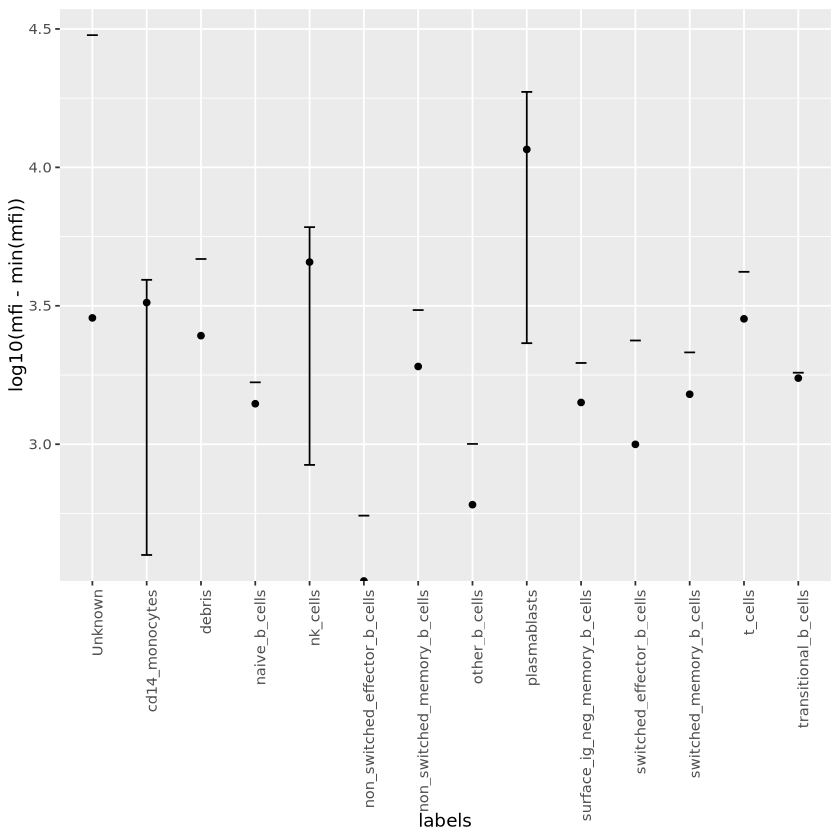

In [37]:
quiet_library(ggplot2)
ggplot() +
  geom_point(
      data = lg,
      aes(x = labels,
          y = log10(mfi - min(mfi)))
  ) +
  geom_errorbar(
      data = lg,
      aes(x = labels,
          ymin = log10(mfi - mfi_stdev),
          ymax = log10(mfi + mfi_stdev)),
      width = 0.2
  ) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

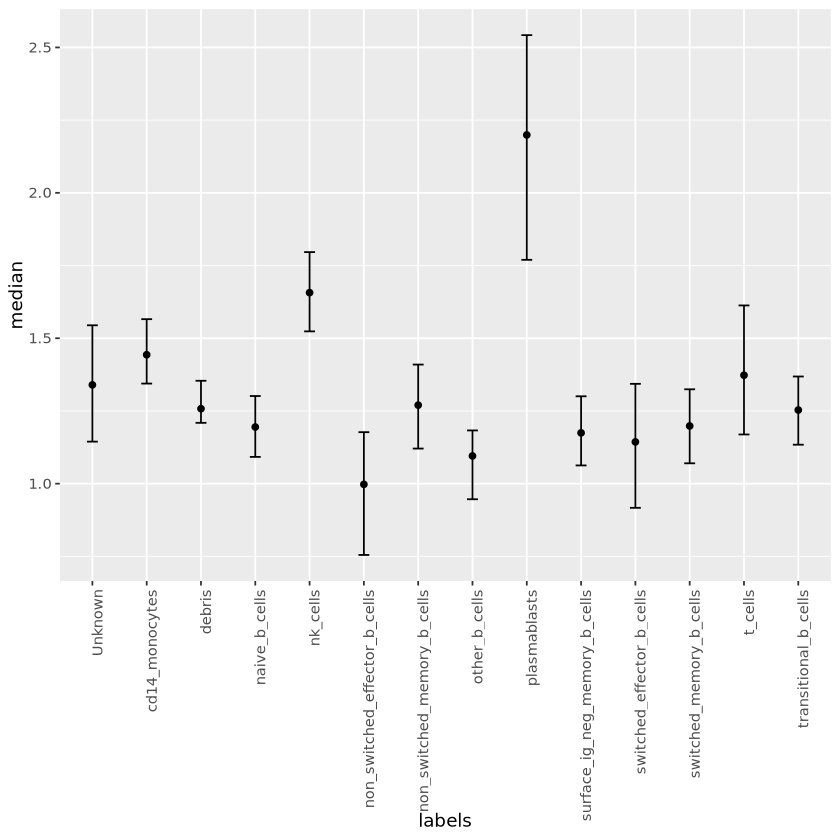

In [108]:
quiet_library(ggplot2)
ggplot() +
  geom_point(
      data = lg,
      aes(x = labels,
          y = median)
  ) +
  geom_errorbar(
      data = lg,
      aes(x = labels,
          ymin = q25,
          ymax = q75),
      width = 0.2
  ) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

In [70]:
value_columns <- setdiff(names(test), c("sample_id", "cell_id", "barcode", "Time", "labels"))

In [71]:
value_columns

[1] "FSC-A"                 "FSC-H"                 "FSC-W"                
 [4] "SSC-A"                 "SSC-B-A"               "SSC-B-H"              
 [7] "SSC-B-W"               "SSC-H"                 "SSC-W"                
[10] "CD85j_logicle"         "CD40_logicle"          "CD19_logicle"         
[13] "CD14_logicle"          "CD38_logicle"          "CD45_logicle"         
[16] "IgM_logicle"           "CD56_logicle"          "CD24_logicle"         
[19] "CD319_logicle"         "CD20_logicle"          "CD269 (BCMA)_logicle" 
[22] "IgD_logicle"           "CD268 (BR3)_logicle"   "CD71_logicle"         
[25] "CD274 (PD-L1)_logicle" "CD3_logicle"           "HLA-DR_logicle"       
[28] "IgA_logicle"           "Viability_logicle"     "CD27_logicle"         
[31] "CD10_logicle"          "CD21_logicle"          "CD86_logicle"         
[34] "IgG_logicle"

In [ ]:
mfi_list <- map(
    value_columns,
    function(val) {
        test %>%
          group_by(sample_id, labels) %>%
          summarise(across(value_columns, ~ mean(.x, na.rm = TRUE)), .groups = "keep")
    }
)

## Build tar file for each panel

First, copy and rename files

In [30]:
cohort_names <- c(
    "BR1" = "Young-Adult",
    "BR2" = "Older-Adult",
    "UP1" = "Pediatric"
)

In [31]:
copy_flow_file <- function(
    in_file,
    sample_meta,
    cohort_names
) {
    in_uuid <- sub("/home/workspace/input/[0-9]+/[^/]+/(.+)/AIFI.+", "\\1", in_file)
    sample_idx <- which(sample_meta$file.id == in_uuid)

    cohort <- cohort_names[sample_meta$cohort.cohortGuid[sample_idx]]
    subject <- sample_meta$subject.subjectGuid[sample_idx]
    visit <- sample_meta$sample.visitName[sample_idx]
    visit <- gsub(" ", "-", visit)
    kit <- sample_meta$sample.sampleKitGuid[sample_idx]
    panel <- sample_meta$file.panel[sample_idx]

    out_file <- paste0(cohort, "_", subject, "_", visit, "_", kit, "_", panel, ".fcs")
    out_path <- paste0("output/human_immune_health_atlas_flow-labeled-events_panel-", panel , "/", out_file)

    file.copy(in_file, out_path)
}

In [32]:
panel_dirs <- map(
    c("PB1", "PM1", "PS1", "PT1"),
    function(panel) {
        paste0("output/human_immune_health_atlas_flow-labeled-events_panel-", panel)
    }
)
names(panel_dirs) <- c("PB1", "PM1", "PS1", "PT1")

In [33]:
walk2(
    events_files, names(events_files),
    function(fileset, panel) {
        
        panel_dir <- panel_dirs[[panel]]
        if(!dir.exists(panel_dir)) {
            dir.create(panel_dir)
            panel_file <- panel_files[[panel]]
            file.copy(panel_file, paste0(panel_dir, "/", basename(panel_file)))
        }
        
        walk(
            fileset,
            copy_flow_file,
            sample_meta = selected_event_desc,
            cohort_names = cohort_names
        )
    }
)

Then, generate .tar bundles. Compression (.tar.gz) takes a lot of time, but has minimal effects on the output file size, as most of the data is already compressed in the .fcs files.

In [34]:
panel_tars <- map(
    panel_dirs,
    function(d) {
        paste0(d, ".tar")
    }
)

In [35]:
walk2(
    panel_dirs, panel_tars,
    function(dir, tar) {
        system(paste("tar -cf", tar, dir))
    }
)

## Upload data to HISE

In [36]:
study_space_uuid <- "64097865-486d-43b3-8f94-74994e0a72e0"
title <- paste("Imm. Health Atlas Flow Labeled Events files", Sys.Date())

In [37]:
search_id <- ids::proquint(n_words = 3)

In [43]:
search_id

[1] "dudan-dimuz-porih"

In [38]:
in_list <- as.list(
    selected_event_desc[["file.id"]]
)

In [39]:
out_list <- c(panel_tars, list(selected_event_csv))

In [40]:
out_list

$PB1
[1] "output/human_immune_health_atlas_flow-fcs_panel-PB1.tar"

$PM1
[1] "output/human_immune_health_atlas_flow-fcs_panel-PM1.tar"

$PS1
[1] "output/human_immune_health_atlas_flow-fcs_panel-PS1.tar"

$PT1
[1] "output/human_immune_health_atlas_flow-fcs_panel-PT1.tar"

[[5]]
[1] "output/human_immune_health_atlas_flow-fcs_file-meta_2024-10-29.csv"

In [41]:
uploadFiles(
    files = out_list,
    studySpaceId = study_space_uuid,
    title = title,
    inputFileIds = in_list,
    store = "project",
    destination = search_id
)

$Message
[1] "General Okay-ness"

$VisualizationId
[1] "00000000-0000-0000-0000-000000000000"

$AbstractionId
[1] "00000000-0000-0000-0000-000000000000"

$TraceId
[1] "75ef4fa8-fa34-4eef-af91-9e19b3994916"

$ProcessId
[1] "5575e9e0-6115-4e4a-9f52-5fb023e0bce4"

$WorkflowId
[1] "f526ff55-fa34-48fa-8288-3b6562d8cf77"

$FileIds
$FileIds[[1]]
[1] "7fae0c52-fe3c-494c-a4ad-4235a1eb3b41"

$FileIds[[2]]
[1] "87b8dd66-14af-4243-961e-e1eace33202a"

$FileIds[[3]]
[1] "c5fe34ae-4251-4dc9-912d-2dbb85afe418"

$FileIds[[4]]
[1] "81929c4f-d3f4-415d-9761-8e6f40ed617f"

$FileIds[[5]]
[1] "2cc9a15f-28f3-43ab-b2e2-5e7c0d0490a2"

In [42]:
sessionInfo()

R version 4.1.3 (2022-03-10)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 24.04 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/r_flow/lib/libopenblasp-r0.3.20.so

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] purrr_0.3.4 dplyr_1.0.8 hise_2.16.0

loaded via a namespace (and not attached):
 [1] Rcpp_1.0.8.3     plyr_1.8.7       pillar_1.7.0     compiler_4.1.3  
 [5] base64enc_0.1-3  bitops_1.0-7     tools_4.1.3      digest_0.6.29   
 [9] uuid_1.1-0       jsonlite_1.8.0   evaluate_0.15    lifecycle_1.0.1 
[13] tibble_3.1.6     pkgconfig_2.0.3  rlang_1.0.2      IRdisplay_1.1   
[17] cli_3.2.0        DBI